In [1]:
from functools import reduce
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.categories import subcat_to_cat

import pickle

In [ ]:
# preds_path_ls = [
#     ('raw 0 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_0sh.bin'),
#     ('raw 5 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_5sh.bin'),
#     ('LoRA 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg13_0sh.bin'),
#     ('LoRA 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg13_5sh.bin'),
#     ('GSOFT 0 shot', r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg0_0sh.bin'),
#     ('GSOFT 5 shot', r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg0_5sh.bin'),
# ]

# preds_path_ls = [
#     ('raw 0 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_0sh.bin'),
#     ('raw 5 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_5sh.bin'),
#     ('LoRA 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg17_0sh.bin'),
#     ('LoRA 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg17_5sh.bin'),
#     ('LoRA-code 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-code-ift-MMLU_0sh.bin'),
#     ('LoRA-code 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-code-ift-MMLU_5sh.bin'),
#     ('GSOFT-code 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-code-ift-MMLU_0sh.bin'),
#     ('GSOFT-code 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-code-ift-MMLU_5sh.bin'),
#     # ('LoRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-OOD-MMLU_0sh.bin'),
#     # ('LoRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-OOD-MMLU_5sh.bin'),
#     # ('DoRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\DoRA-cfg18-OOD-MMLU_0sh.bin'),
#     # ('DoRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\DoRA-cfg18-OOD-MMLU_5sh.bin'),
#     # ('GSOFT-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-OOD-MMLU_0sh.bin'),
#     # ('GSOFT-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-OOD-MMLU_5sh.bin'),
#     # ('VeRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\VeRA-cfg1-OOD-MMLU_0sh.bin'),
#     # ('VeRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\VeRA-cfg1-OOD-MMLU_5sh.bin'),
# ]

LoRA_cfg = 2
GSOFT_cfg = 16

preds_path_ls = [
    ('Raw 1b',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_1b_5sh.bin'),
    # ('LoRA_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-CR_5sh.bin'),
    # ('GSOFT_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-CR_5sh.bin'),
]

max_step = 16_000
for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'LoRA_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-st{st}-MMLU_5sh.bin')
    )

for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'GSOFT_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-st{st}-MMLU_5sh.bin')
    )

In [3]:
preds_dfs = {}

for run_name, preds_path in preds_path_ls:
    with open(preds_path, 'rb') as f:
        preds_dfs[run_name] = pickle.load(file=f)

        print(f"{run_name:16}: {preds_dfs[run_name].shape=}")

Raw 1b          : preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-2000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-4000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-6000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-8000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-10000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-12000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-14000: preds_dfs[run_name].shape=(14042, 7)
LoRA_1b-code st-16000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-2000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-4000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-6000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-8000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-10000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-12000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-14000: preds_dfs[run_name].shape=(14042, 7)
GSOFT_1b-code st-16000: preds_dfs[run_name].sh

In [4]:
idx = 6

print(preds_dfs['Raw 1b']['text'][idx])
print(preds_dfs['Raw 1b']['model_pred'][idx])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

The following are multiple choice questions (with answers) about abstract_algebra. Output 'A', 'B', 'C', or 'D'. Full answer not needed.<|eot_id|><|start_header_id|>user<|end_header_id|>

Find all c in Z_3 such that Z_3[x]/(x^2 + c) is a field.
A. 0
B. 1
C. 2
D. 3<|eot_id|><|start_header_id|>assistant<|end_header_id|>

B<|eot_id|><|start_header_id|>user<|end_header_id|>

Statement 1 | If aH is an element of a factor group, then |aH| divides |a|. Statement 2 | If H and K are subgroups of G then HK is a subgroup of G.
A. True, True
B. False, False
C. True, False
D. False, True<|eot_id|><|start_header_id|>assistant<|end_header_id|>

B<|eot_id|><|start_header_id|>user<|end_header_id|>

Statement 1 | Every element of a group generates a cyclic subgroup of the group. Statement 2 | The symmetric group S_10 has 10 elements.
A. True, True
B. False, False
C. True, False
D. False, True<|eot_id|><|start_header_id|>assistant<|end_header_i

In [5]:
# tmp_idxs = preds_dfs['Raw 1b 0 shot']['model_pred'].apply(
#     lambda p: re.match('[ABCD]', p['generated_text']) is not None
# )

# preds_dfs['Raw 1b 0 shot']['model_pred'][~tmp_idxs].shape

In [6]:
def get_category(subject):
    return subcat_to_cat[subject]

# OOD_part = re.compile('The correct answer is [ABCD]')
# OOD_part_len = len('The correct answer is ')

OOD_parts = [
    (re.compile('The correct answer is [ABCD]'), len('The correct answer is ')),
    (re.compile('The answer is [ABCD]'), len('The answer is ')),
    (re.compile('The solution is [ABCD]'), len('The solution is ')),
]

def get_pred(p):
    for OOD_part, OOD_part_len in OOD_parts:
        if OOD_part.search(p):
            return p[OOD_part_len]
    
    return p[0]

def processor(row: pd.DataFrame):
    generated_text = row['model_pred']['generated_text']
    generated_text = generated_text.strip()
    

    # generated_text	subject	pred	true	corr	category
    category = get_category(row['subject'])
    pred = get_pred(generated_text)
    true = chr(ord('A') + row['answer'])
    corr = int(pred == true)

    return {
        'generated_text': generated_text,
        'subject': row['subject'],
        'pred': pred,
        'true': true,
        'corr': corr,
        'category': category
    }

In [7]:
print(*preds_dfs.keys(), sep='\n')

Raw 1b
LoRA_1b-code st-2000
LoRA_1b-code st-4000
LoRA_1b-code st-6000
LoRA_1b-code st-8000
LoRA_1b-code st-10000
LoRA_1b-code st-12000
LoRA_1b-code st-14000
LoRA_1b-code st-16000
GSOFT_1b-code st-2000
GSOFT_1b-code st-4000
GSOFT_1b-code st-6000
GSOFT_1b-code st-8000
GSOFT_1b-code st-10000
GSOFT_1b-code st-12000
GSOFT_1b-code st-14000
GSOFT_1b-code st-16000


In [8]:
for run_name in preds_dfs.keys():
    preds_dfs[run_name] = preds_dfs[run_name].apply(processor, axis=1, result_type='expand')

In [9]:
preds_dfs['Raw 1b'].head()

,generated_text,subject,pred,true,corr,category
0,C,abstract_algebra,C,B,0,STEM
1,C,abstract_algebra,C,C,1,STEM
2,C,abstract_algebra,C,D,0,STEM
3,C,abstract_algebra,C,B,0,STEM
4,To find the product of the given polynomials i...,abstract_algebra,T,B,0,STEM


In [10]:
# preds_dfs['LoRA_1b-CR'].head()

In [11]:
acc_by_subjects = pd.DataFrame({
    'subject': list(set.union(
        *map(
            lambda df: set(df['subject']),
            preds_dfs.values()
        )
    ))
})

print(f"Subjects: {acc_by_subjects['subject']}")

for run_name, preds_df in preds_dfs.items():
    acc_df = preds_df[['subject', 'corr']].groupby(['subject'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    acc_by_subjects = acc_by_subjects.merge(
        acc_df,
        left_on='subject',
        right_on='subject',
        how='right'
    )

Subjects: 0                         moral_scenarios
1                       us_foreign_policy
2                          moral_disputes
3                            econometrics
4                  high_school_statistics
5                              management
6                            global_facts
7                              prehistory
8                               astronomy
9                        abstract_algebra
10                       public_relations
11             high_school_microeconomics
12                               virology
13                 elementary_mathematics
14                professional_accounting
15                       college_medicine
16                       professional_law
17           high_school_european_history
18                             philosophy
19                       security_studies
20               college_computer_science
21                high_school_mathematics
22                 electrical_engineering
23                    hi

In [12]:
acc_by_subjects

,subject,Raw 1b,LoRA_1b-code st-2000,LoRA_1b-code st-4000,LoRA_1b-code st-6000,LoRA_1b-code st-8000,LoRA_1b-code st-10000,LoRA_1b-code st-12000,LoRA_1b-code st-14000,LoRA_1b-code st-16000,GSOFT_1b-code st-2000,GSOFT_1b-code st-4000,GSOFT_1b-code st-6000,GSOFT_1b-code st-8000,GSOFT_1b-code st-10000,GSOFT_1b-code st-12000,GSOFT_1b-code st-14000,GSOFT_1b-code st-16000
0,abstract_algebra,0.260000,0.260000,0.340000,0.330000,0.340000,0.320000,0.310000,0.310000,0.300000,0.280000,0.220000,0.210000,0.170000,0.190000,0.200000,0.200000,0.190000
1,anatomy,0.488889,0.466667,0.466667,0.466667,0.459259,0.451852,0.451852,0.429630,0.437037,0.474074,0.503704,0.474074,0.511111,0.533333,0.533333,0.533333,0.533333
2,astronomy,0.526316,0.546053,0.500000,0.473684,0.467105,0.427632,0.447368,0.440789,0.440789,0.526316,0.519737,0.546053,0.532895,0.519737,0.519737,0.519737,0.519737
3,business_ethics,0.500000,0.460000,0.460000,0.420000,0.440000,0.440000,0.440000,0.440000,0.420000,0.510000,0.500000,0.470000,0.460000,0.450000,0.450000,0.450000,0.450000
4,clinical_knowledge,0.486792,0.498113,0.441509,0.456604,0.449057,0.437736,0.430189,0.456604,0.456604,0.501887,0.509434,0.509434,0.513208,0.513208,0.513208,0.513208,0.513208
5,college_biology,0.430556,0.458333,0.465278,0.444444,0.423611,0.409722,0.395833,0.402778,0.409722,0.479167,0.486111,0.472222,0.458333,0.458333,0.458333,0.465278,0.451389
6,college_chemistry,0.270000,0.280000,0.230000,0.220000,0.200000,0.230000,0.220000,0.240000,0.240000,0.310000,0.380000,0.410000,0.420000,0.440000,0.430000,0.430000,0.430000
7,college_computer_science,0.240000,0.310000,0.400000,0.370000,0.380000,0.330000,0.330000,0.320000,0.320000,0.240000,0.250000,0.260000,0.320000,0.360000,0.360000,0.380000,0.370000
8,college_mathematics,0.240000,0.320000,0.320000,0.330000,0.300000,0.320000,0.300000,0.310000,0.290000,0.290000,0.300000,0.290000,0.300000,0.260000,0.280000,0.280000,0.280000
9,college_medicine,0.393064,0.468208,0.433526,0.375723,0.375723,0.393064,0.393064,0.375723,0.381503,0.462428,0.479769,0.479769,0.456647,0.450867,0.456647,0.456647,0.450867


In [13]:
acc_by_categories = pd.DataFrame({
    'category': list(set.union(
        *map(
            lambda df: set(df['category']),
            preds_dfs.values()
        )
    ))
})

for run_name, preds_df in preds_dfs.items():
    acc_df = preds_df[['category', 'corr']].groupby(['category'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    acc_by_categories = acc_by_categories.merge(
        acc_df,
        left_on='category',
        right_on='category',
        how='right'
    )

In [14]:
acc_by_categories.loc[:, list(filter(
    lambda s: ('5 shot' not in s),
    acc_by_categories.columns
))]

,category,Raw 1b,LoRA_1b-code st-2000,LoRA_1b-code st-4000,LoRA_1b-code st-6000,LoRA_1b-code st-8000,LoRA_1b-code st-10000,LoRA_1b-code st-12000,LoRA_1b-code st-14000,LoRA_1b-code st-16000,GSOFT_1b-code st-2000,GSOFT_1b-code st-4000,GSOFT_1b-code st-6000,GSOFT_1b-code st-8000,GSOFT_1b-code st-10000,GSOFT_1b-code st-12000,GSOFT_1b-code st-14000,GSOFT_1b-code st-16000
0,STEM,0.358516,0.356528,0.358847,0.346918,0.334327,0.333665,0.330683,0.328363,0.325712,0.387011,0.382041,0.389993,0.389662,0.390656,0.392644,0.388999,0.387011
1,humanities,0.414665,0.411052,0.386397,0.378533,0.372582,0.368332,0.361530,0.365143,0.360043,0.429968,0.426780,0.424655,0.421679,0.418278,0.419129,0.419979,0.419979
2,"other (business, health, misc.)",0.502468,0.497532,0.479025,0.452190,0.433374,0.433374,0.427514,0.427205,0.425972,0.521592,0.524985,0.516965,0.516348,0.512338,0.509254,0.508328,0.507711
3,social sciences,0.488463,0.480663,0.465388,0.443614,0.425089,0.423789,0.422164,0.422814,0.420539,0.499188,0.502437,0.504387,0.506012,0.505037,0.506662,0.504387,0.503737


In [15]:
acc_by_categories.loc[:, list(filter(
    lambda s: ('0 shot' not in s),
    acc_by_categories.columns
))]

,category,Raw 1b,LoRA_1b-code st-2000,LoRA_1b-code st-4000,LoRA_1b-code st-6000,LoRA_1b-code st-8000,LoRA_1b-code st-10000,LoRA_1b-code st-12000,LoRA_1b-code st-14000,LoRA_1b-code st-16000,GSOFT_1b-code st-2000,GSOFT_1b-code st-4000,GSOFT_1b-code st-6000,GSOFT_1b-code st-8000,GSOFT_1b-code st-10000,GSOFT_1b-code st-12000,GSOFT_1b-code st-14000,GSOFT_1b-code st-16000
0,STEM,0.358516,0.356528,0.358847,0.346918,0.334327,0.333665,0.330683,0.328363,0.325712,0.387011,0.382041,0.389993,0.389662,0.390656,0.392644,0.388999,0.387011
1,humanities,0.414665,0.411052,0.386397,0.378533,0.372582,0.368332,0.361530,0.365143,0.360043,0.429968,0.426780,0.424655,0.421679,0.418278,0.419129,0.419979,0.419979
2,"other (business, health, misc.)",0.502468,0.497532,0.479025,0.452190,0.433374,0.433374,0.427514,0.427205,0.425972,0.521592,0.524985,0.516965,0.516348,0.512338,0.509254,0.508328,0.507711
3,social sciences,0.488463,0.480663,0.465388,0.443614,0.425089,0.423789,0.422164,0.422814,0.420539,0.499188,0.502437,0.504387,0.506012,0.505037,0.506662,0.504387,0.503737


In [16]:
total_res = pd.DataFrame(columns=['run_name', 'accuracy', 'correctness'])

for run_name, preds_df in preds_dfs.items():
    total_accuracy = preds_df['corr'].mean()
    total_correctness = (preds_df['pred'].isin(['A', 'B', 'C', 'D'])).mean()

    total_res = pd.concat([
        total_res,
        pd.DataFrame({
            'run_name': [run_name],
            'accuracy': [total_accuracy],
            'correctness': [total_correctness],
        })
    ])

C:\Users\Vladimir\AppData\Local\Temp\ipykernel_14756\1869384032.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_res = pd.concat([


In [17]:
total_res

,run_name,accuracy,correctness
0,Raw 1b,0.439040,0.997935
0,LoRA_1b-code st-2000,0.434553,0.998932
0,LoRA_1b-code st-4000,0.419171,0.999858
0,LoRA_1b-code st-6000,0.403005,0.998861
0,LoRA_1b-code st-8000,0.389902,0.999359
0,LoRA_1b-code st-10000,0.388050,0.998861
0,LoRA_1b-code st-12000,0.383421,0.997721
0,LoRA_1b-code st-14000,0.384205,0.997792
0,LoRA_1b-code st-16000,0.381142,0.997864
0,GSOFT_1b-code st-2000,0.457057,0.999074


In [18]:
# preds_dfs['GSOFT_1b-CR'][preds_dfs['GSOFT_1b-CR'].pred != preds_dfs['GSOFT_1b-CR_old'].pred]

In [19]:
scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].accuracy[0]]
scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('MMLU 5sh accuracy')

KeyError: 0

In [20]:
scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].accuracy[0]]
scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('MMLU 5sh accuracy')

KeyError: 0

In [21]:
LoRA_scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].accuracy[0]]
LoRA_scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].accuracy[0]]
GSOFT_scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA-tuned'
)

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('MMLU 5sh accuracy')

KeyError: 0

Text(0, 0.5, 'MMLU 5sh accuracy')

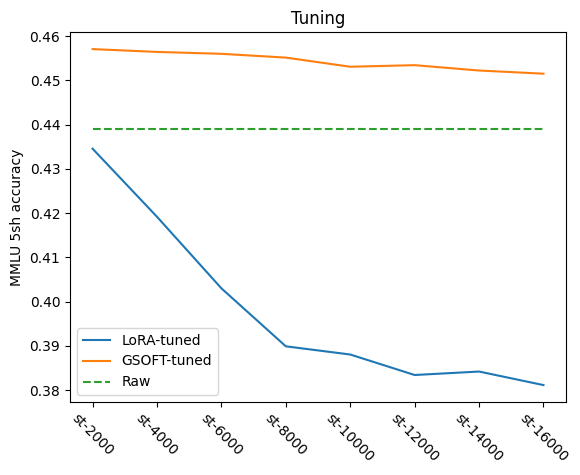

In [22]:
LoRA_scores = [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(2_000, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA-tuned'
)

sns.lineplot(
    x=range(2_000, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT-tuned'
)

sns.lineplot(
    x=[2_000, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(2_000, max_step+1,2000),
    labels=[f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('MMLU 5sh accuracy')

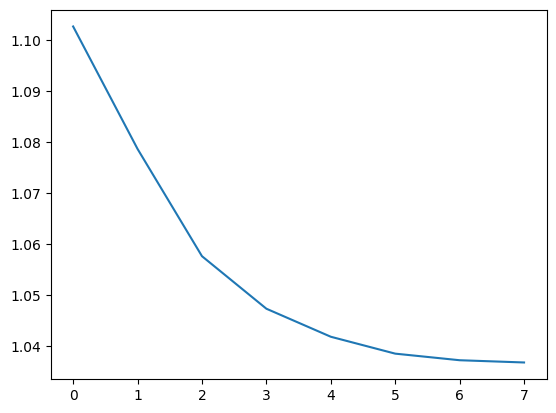

In [23]:
GSOFT_loss = np.array([
    1.1026, 1.07861, 1.0576, 1.04731, 1.04182, 1.03851, 1.03722, 1.03678
])

plt.plot(GSOFT_loss)